# Task 2.2 — Reproduction of Core Contribution

**Paper**: *Advice Refinement in Knowledge-Based SVMs* — Kunapuli, Maclin & Shavlik (NIPS 2011)

**Contribution being reproduced:** The arkSVM-sla algorithm (Algorithm 1 in the paper) — advice refinement via successive linear programming. This is the first of the two novel solvers proposed in the paper for the arkSVM formulation (Eq. 8).

**Evaluation metric:** Testing error (%) on a holdout test set, consistent with the experimental setup in Figures 3–4 of the paper. We evaluate SVM, KBSVM, and arkSVM-sla across varying training set sizes to replicate the paper's core finding: advice-refining methods help most when labeled data is scarce.

In [1]:
# ── Imports and random seed ──
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.svm import LinearSVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Hyperparameters (defined here, not scattered across cells) ──
LAMBDA = 1.0    # data trust (Eq. 4, 8)
MU     = 0.1    # advice trust (Eq. 4, 8)
NU     = 0.1    # refinement penalty (Eq. 8)
EPSILON = 0.01  # convergence tolerance (Algorithm 1, line 6)
MAX_ITER = 10   # max iterations for arkSVM-sla

print(f"Hyperparameters: λ={LAMBDA}, μ={MU}, ν={NU}, ε={EPSILON}, max_iter={MAX_ITER}")

Hyperparameters: λ=1.0, μ=0.1, ν=0.1, ε=0.01, max_iter=10


All hyperparameters are set in a single place for reproducibility. λ controls trust in the data, μ controls trust in the advice, and ν controls how much refinement is allowed (Eq. 8). These correspond directly to the parameters in the paper's objective function.

In [2]:
# ── Load and preprocess data (from Task 2.1) ──
cancer = load_breast_cancer()
y_signed = np.where(cancer.target == 0, -1, 1)  # malignant=-1, benign=+1

# Use 4 key features to keep the LP tractable and the results interpretable
FEAT_IDX = [0, 1, 7, 20]  # mean_radius, mean_texture, mean_concave_pts, worst_radius
FEAT_NAMES = [cancer.feature_names[i] for i in FEAT_IDX]
X = cancer.data[:, FEAT_IDX]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y_signed, test_size=0.3, random_state=RANDOM_SEED, stratify=y_signed)

n_features = len(FEAT_IDX)
print(f"Using {n_features} features: {FEAT_NAMES}")
print(f"Train: {len(X_train_full)}, Test: {len(X_test)}")

Using 4 features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean concave points'), np.str_('worst radius')]
Train: 398, Test: 171


I load the Breast Cancer dataset and select 4 features that are most relevant to the expert advice rules (see below). I standardise them so that the 1-norm regularisation in Eq. 3–4 treats all features equally. Using a feature subset is a simplification compared to the full 30-feature dataset — the paper's KBSVM and arkSVM formulations work with any feature count, but fewer features make the LP sub-problems faster and the refined advice easier to interpret.

In [3]:
# ── Expert advice rules as polyhedral constraints (Eq. 2) ──
# Format: D_i x <= d_i  =>  class = z_i
# Feature order: [mean_radius, mean_texture, mean_concave_pts, worst_radius]

advice_sets = [
    # Rule 1: mean_radius <= -0.5 AND mean_concave_pts <= -0.3 => benign (+1)
    (np.array([[1,0,0,0], [0,0,1,0]], dtype=float), np.array([-0.5, -0.3]), 1),
    # Rule 2: mean_radius >= 0.5 AND mean_concave_pts >= 0.3 => malignant (-1)
    (np.array([[-1,0,0,0], [0,0,-1,0]], dtype=float), np.array([-0.5, -0.3]), -1),
    # Rule 3: worst_radius >= 0.7 AND mean_texture >= 0.3 => malignant (-1)
    (np.array([[0,0,0,-1], [0,-1,0,0]], dtype=float), np.array([-0.7, -0.3]), -1),
    # Rule 4: worst_radius <= -0.3 AND mean_texture <= 0.0 => benign (+1)
    (np.array([[0,0,0,1], [0,1,0,0]], dtype=float), np.array([-0.3, 0.0]), 1),
]

print(f"{len(advice_sets)} advice sets defined (2 per class).")
for i, (D, d, z) in enumerate(advice_sets):
    print(f"  Rule {i+1}: k_i={D.shape[0]} constraints, z_i={'+1 (benign)' if z==1 else '-1 (malignant)'}")

4 advice sets defined (2 per class).
  Rule 1: k_i=2 constraints, z_i=+1 (benign)
  Rule 2: k_i=2 constraints, z_i=-1 (malignant)
  Rule 3: k_i=2 constraints, z_i=-1 (malignant)
  Rule 4: k_i=2 constraints, z_i=+1 (benign)


Each rule follows the form D_i x ≤ d_i ⇒ z_i (Eq. 2, Section 2). We have 4 rules with 2 constraints each, similar in structure to the paper's 6 diabetes rules (Section 4.2). The thresholds are based on medical knowledge about breast tumour characteristics but are intentionally approximate — so the refinement mechanism has something to improve.

For the matrix encoding: "feature ≥ threshold" becomes −feature ≤ −threshold (flipping the sign to get the D x ≤ d form).

In [4]:
# ── Helper: testing error ──
def test_error(y_true, y_pred):
    return np.mean(y_true != y_pred) * 100

# ══════════════════════════════════════════════════════════════════
# METHOD 1: Standard SVM (Eq. 3)
# ══════════════════════════════════════════════════════════════════
def train_svm(X, y, C=1.0):
    """
    Standard linear SVM baseline.
    Eq. 3: min ||w||_2^2 + C * sum(xi)
           s.t. y_j(w'x_j - b) + xi_j >= 1,  xi >= 0
    Uses sklearn's LinearSVC (L2 hinge loss, equivalent to standard SVM).
    """
    clf = LinearSVC(penalty='l2', loss='hinge', C=C, dual=True,
                    random_state=RANDOM_SEED, max_iter=5000)
    clf.fit(X, y)
    return clf.coef_.flatten(), clf.intercept_[0]

# Quick test
w_svm, b_svm = train_svm(X_train_full, y_train_full)
pred = np.sign(X_test @ w_svm - b_svm)
print(f"SVM test error: {test_error(y_test, pred):.1f}%")

SVM test error: 3.5%


This is the baseline SVM from Eq. 3 — it uses only the labeled data with no advice. The paper uses a 1-norm SVM (‖w‖₁ regularisation), but I use sklearn's L2-hinge SVM here for convenience. The paper's main point is the *relative* improvement from advice refinement, which holds regardless of the specific regulariser. This baseline represents the "svm" curve in Figures 3–4 of the paper.

In [5]:
# ══════════════════════════════════════════════════════════════════
# METHOD 2: KBSVM — Knowledge-Based SVM (Eq. 4)
# ══════════════════════════════════════════════════════════════════
#
# min ||w||_1 + lambda * e'xi + mu * sum_i(e'eta_i + zeta_i)
# s.t. Y(Xw - be) + xi >= e              [data constraints]
#      -eta_i <= D_i' u_i + z_i w <= eta_i  [advice direction, n constraints per set]
#      -d_i' u_i - z_i b + zeta_i >= 1      [advice implication, 1 per set]
#      xi, u_i, eta_i, zeta_i >= 0
#
# To solve as an LP: split w = w+ - w-, so ||w||_1 = e'w+ + e'w-
# All variables are non-negative.

def train_kbsvm(X, y, advice_sets, lam=LAMBDA, mu=MU):
    """
    KBSVM (Eq. 4) via scipy.optimize.linprog.
    Returns (w, b, u_list) or (None, None, None) if LP infeasible.
    """
    l, n = X.shape
    ks = [D.shape[0] for D, d, z in advice_sets]
    m = len(advice_sets)
    
    # Variable layout: [w+(n), w-(n), b+(1), b-(1), xi(l),
    #                    u_1(k1), eta_1(n), zeta_1(1), u_2(k2), ...]
    base = 2*n + 2 + l
    offset = base
    adv_idx = []
    for k in ks:
        adv_idx.append((slice(offset, offset+k), slice(offset+k, offset+k+n), offset+k+n, k))
        offset += k + n + 1
    n_vars = offset
    
    # Objective
    c = np.zeros(n_vars)
    c[:n] = 1.0; c[n:2*n] = 1.0   # ||w||_1
    c[2*n+2:2*n+2+l] = lam         # lambda * e'xi
    for iu, ie, iz, k in adv_idx:
        c[ie] = mu       # mu * e'eta_i
        c[iz] = mu       # mu * zeta_i
    
    # Constraints (all as A_ub @ x <= b_ub)
    A_rows, b_rows = [], []
    
    # Data: y_j(w'x_j - b) + xi_j >= 1  =>  -y_j X_j w+ + y_j X_j w- + y_j b+ - y_j b- - xi_j <= -1
    for j in range(l):
        row = np.zeros(n_vars)
        row[:n] = -y[j] * X[j]
        row[n:2*n] = y[j] * X[j]
        row[2*n] = y[j]; row[2*n+1] = -y[j]
        row[2*n+2+j] = -1.0
        A_rows.append(row); b_rows.append(-1.0)
    
    # Advice constraints per set
    for s, (D, d, z) in enumerate(advice_sets):
        iu, ie, iz, k = adv_idx[s]
        
        # D_i' u_i + z_i w <= eta_i  AND  -(D_i' u_i + z_i w) <= eta_i
        for jf in range(n):
            # Upper bound: D_col'u + z*w_j - eta_j <= 0
            row = np.zeros(n_vars)
            for kk in range(k): row[iu.start+kk] = D[kk, jf]
            row[jf] = z; row[n+jf] = -z
            row[ie.start+jf] = -1.0
            A_rows.append(row); b_rows.append(0.0)
            
            # Lower bound: -(D_col'u + z*w_j) - eta_j <= 0
            row2 = np.zeros(n_vars)
            for kk in range(k): row2[iu.start+kk] = -D[kk, jf]
            row2[jf] = -z; row2[n+jf] = z
            row2[ie.start+jf] = -1.0
            A_rows.append(row2); b_rows.append(0.0)
        
        # -d_i' u_i - z_i b + zeta_i >= 1  =>  d'u + z*b - zeta <= -1
        row3 = np.zeros(n_vars)
        for kk in range(k): row3[iu.start+kk] = d[kk]
        row3[2*n] = z; row3[2*n+1] = -z
        row3[iz] = -1.0
        A_rows.append(row3); b_rows.append(-1.0)
    
    res = linprog(c, A_ub=np.array(A_rows), b_ub=np.array(b_rows),
                  bounds=[(0, None)] * n_vars, method='highs')
    
    if res.success:
        x = res.x
        w = x[:n] - x[n:2*n]
        b = x[2*n] - x[2*n+1]
        u_list = [x[iu] for iu, _, _, _ in adv_idx]
        return w, b, u_list
    else:
        return None, None, None

# Quick test
w_kb, b_kb, u_kb = train_kbsvm(X_train_full, y_train_full, advice_sets)
if w_kb is not None:
    pred = np.sign(X_test @ w_kb - b_kb)
    print(f"KBSVM test error: {test_error(y_test, pred):.1f}%")
    print(f"Support constraints (non-zero u_i norms): {[f'{np.linalg.norm(u):.3f}' for u in u_kb]}")
else:
    print("KBSVM LP infeasible")

KBSVM test error: 5.3%
Support constraints (non-zero u_i norms): ['1.567', '1.567', '4.496', '4.496']


This implements the KBSVM from Eq. 4 (Section 2) using `scipy.optimize.linprog`. I convert the optimisation to standard LP form by splitting w = w⁺ − w⁻ (both ≥ 0) so that ‖w‖₁ = e'w⁺ + e'w⁻ becomes linear. The three constraint groups match the paper exactly:

1. **Data constraints** (first row of Eq. 4): Y(Xw − be) + ξ ≥ e
2. **Advice direction** (second row): −η_i ≤ D_i'u_i + z_i w ≤ η_i — these ensure the advice vectors u_i align with the classifier
3. **Advice implication** (third row): −d_i'u_i − z_i b + ζ_i ≥ 1 — this is the Farkas-theorem conversion of D_i x ≤ d_i ⇒ z_i(w'x − b) ≥ 1

The u_i norms tell us which advice sets are active (non-zero u_i = "support constraints", analogous to support vectors).

In [6]:
# ══════════════════════════════════════════════════════════════════
# METHOD 3: arkSVM-sla — Algorithm 1 (Successive Linear Programming)
# ══════════════════════════════════════════════════════════════════

# ── ESTIMATION STEP (Algorithm 1, Line 4) ──
# Fix (F_i, f_i), solve a KBSVM with refined advice: (D_i - F_i)x <= (d_i - f_i)

def arksvm_estimation_step(X, y, advice_sets, F_list, f_list, lam=LAMBDA, mu=MU):
    """Fix refinement terms, solve KBSVM LP to get updated w, b, u_i."""
    refined_advice = [
        (D - F_list[i], d - f_list[i], z)
        for i, (D, d, z) in enumerate(advice_sets)
    ]
    return train_kbsvm(X, y, refined_advice, lam, mu)

print("Estimation step function defined (Algorithm 1, Line 4)")

Estimation step function defined (Algorithm 1, Line 4)


The **Estimation Step** (Algorithm 1, Line 4) freezes the current refinement terms (F_i^t, f_i^t) and solves for the advice vectors u_i. Because F_i and f_i are fixed, the bilinear products F_i'u_i become linear in u_i, and the whole sub-problem reduces to a standard KBSVM LP. The only difference from a plain KBSVM is that the advice uses the *refined* regions (D_i − F_i^t)x ≤ (d_i − f_i^t) instead of the originals.

In [7]:
# ── REFINEMENT STEP (Algorithm 1, Line 5) ──
# Fix u_i, solve for w, b, F_i, f_i with refinement penalty

def arksvm_refinement_step(X, y, advice_sets, u_list, lam=LAMBDA, mu=MU, nu=NU):
    """Fix u_i, solve LP for w, b, F_i, f_i with ν-penalty on refinement."""
    l, n = X.shape
    m = len(advice_sets)
    ks = [D.shape[0] for D, d, z in advice_sets]
    
    # Variable layout:
    # [w+(n), w-(n), b+(1), b-(1), xi(l),
    #  For each advice set:
    #    F_i+(k_i*n), F_i-(k_i*n), f_i+(k_i), f_i-(k_i), eta_i(n), zeta_i(1)]
    #
    # F_i = F_i+ - F_i-  so  ||F_i||_1 = e'F_i+ + e'F_i-
    # f_i = f_i+ - f_i-  so  ||f_i||_1 = e'f_i+ + e'f_i-
    
    base = 2*n + 2 + l
    offset = base
    adv_idx = []
    for k in ks:
        Fp = offset; offset += k*n
        Fm = offset; offset += k*n
        fp = slice(offset, offset+k); offset += k
        fm = slice(offset, offset+k); offset += k
        eta = slice(offset, offset+n); offset += n
        zeta = offset; offset += 1
        adv_idx.append((Fp, Fm, fp, fm, eta, zeta, k))
    n_vars = offset
    
    # Objective: ||w||_1 + lam*xi + mu*(eta + zeta) + nu*(|F| + |f|)
    c = np.zeros(n_vars)
    c[:n] = 1.0; c[n:2*n] = 1.0
    c[2*n+2:2*n+2+l] = lam
    for Fp, Fm, fp, fm, eta, zeta, k in adv_idx:
        c[Fp:Fp+k*n] = nu   # nu * F_i+
        c[Fm:Fm+k*n] = nu   # nu * F_i-
        c[fp] = nu           # nu * f_i+
        c[fm] = nu           # nu * f_i-
        c[eta] = mu          # mu * eta_i
        c[zeta] = mu         # mu * zeta_i
    
    A_rows, b_rows = [], []
    
    # Data constraints (same as KBSVM)
    for j in range(l):
        row = np.zeros(n_vars)
        row[:n] = -y[j]*X[j]; row[n:2*n] = y[j]*X[j]
        row[2*n] = y[j]; row[2*n+1] = -y[j]; row[2*n+2+j] = -1.0
        A_rows.append(row); b_rows.append(-1.0)
    
    # Advice constraints with FIXED u_i
    for s, (D, d, z) in enumerate(advice_sets):
        Fp, Fm, fp, fm, eta, zeta, k = adv_idx[s]
        u_fixed = u_list[s]
        
        # (D_i - F_i)' u_i + z_i w  =  D_i' u_i - F_i' u_i + z_i w
        # F_i' u: for feature j, sum_kk F_i[kk,j]*u[kk]
        # Since u is fixed, -F_i' u is linear in F_i.
        
        for jf in range(n):
            const = sum(D[kk, jf] * u_fixed[kk] for kk in range(k))
            
            # Upper: (const - F_i'u)_j + z*w_j - eta_j <= 0
            row = np.zeros(n_vars)
            for kk in range(k):
                row[Fp + kk*n + jf] = -u_fixed[kk]  # -(F_i+[kk,jf]*u[kk])
                row[Fm + kk*n + jf] = u_fixed[kk]   # +(F_i-[kk,jf]*u[kk])
            row[jf] = z; row[n+jf] = -z
            row[eta.start+jf] = -1.0
            A_rows.append(row); b_rows.append(-const)
            
            # Lower: -(const - F_i'u)_j - z*w_j - eta_j <= 0
            row2 = np.zeros(n_vars)
            for kk in range(k):
                row2[Fp + kk*n + jf] = u_fixed[kk]
                row2[Fm + kk*n + jf] = -u_fixed[kk]
            row2[jf] = -z; row2[n+jf] = z
            row2[eta.start+jf] = -1.0
            A_rows.append(row2); b_rows.append(const)
        
        # -(d_i - f_i)' u_i - z_i b + zeta_i >= 1
        const_d = d @ u_fixed
        row3 = np.zeros(n_vars)
        for kk in range(k):
            row3[fp.start+kk] = -u_fixed[kk]  # f_i+ contributes +f'u
            row3[fm.start+kk] = u_fixed[kk]   # f_i- contributes -f'u
        row3[2*n] = z; row3[2*n+1] = -z; row3[zeta] = -1.0
        A_rows.append(row3); b_rows.append(-1.0 - const_d)
    
    res = linprog(c, A_ub=np.array(A_rows), b_ub=np.array(b_rows),
                  bounds=[(0, None)] * n_vars, method='highs')
    
    if res.success:
        x = res.x
        w = x[:n] - x[n:2*n]
        b = x[2*n] - x[2*n+1]
        F_list, f_list = [], []
        for Fp, Fm, fp, fm, _, _, k in adv_idx:
            F_list.append(x[Fp:Fp+k*n].reshape(k, n) - x[Fm:Fm+k*n].reshape(k, n))
            f_list.append(x[fp] - x[fm])
        return w, b, F_list, f_list
    else:
        return None, None, None, None

print("Refinement step function defined (Algorithm 1, Line 5)")

Refinement step function defined (Algorithm 1, Line 5)


The **Refinement Step** (Algorithm 1, Line 5) freezes the advice vectors û_i and solves for the refinement terms (F_i, f_i). Since û_i is fixed, the bilinear products F_i'û_i and f_i'û_i are now *linear* in F_i and f_i respectively — so this is again just an LP.

The key addition compared to the KBSVM is the ν-penalty on the refinement terms in the objective (last term in Eq. 8): ν · Σ(‖F_i‖₁ + ‖f_i‖₁). To make |F_i| compatible with linprog, I split each F_i into F_i⁺ − F_i⁻ (both ≥ 0), so ‖F_i‖₁ = e'F_i⁺ + e'F_i⁻. Same trick for f_i.

In [8]:
# ── FULL arkSVM-sla ALGORITHM (Algorithm 1) ──

def train_arksvm_sla(X, y, advice_sets, lam=LAMBDA, mu=MU, nu=NU,
                     epsilon=EPSILON, max_iter=MAX_ITER, verbose=False):
    """
    Full arkSVM-sla: Algorithm 1 from the paper.
    Alternates Estimation and Refinement steps until convergence.
    """
    n = X.shape[1]
    m = len(advice_sets)
    
    # Initialise: F_i = 0, f_i = 0  (Algorithm 1, Line 1)
    F_list = [np.zeros((D.shape[0], n)) for D, d, z in advice_sets]
    f_list = [np.zeros(D.shape[0]) for D, d, z in advice_sets]
    w, b = None, None
    
    for t in range(max_iter):
        # Estimation step (Line 4)
        w, b, u_list = arksvm_estimation_step(X, y, advice_sets, F_list, f_list, lam, mu)
        if w is None:
            if verbose: print(f"  Iter {t+1}: estimation step infeasible")
            break
        
        # Refinement step (Line 5)
        w_new, b_new, F_new, f_new = arksvm_refinement_step(
            X, y, advice_sets, u_list, lam, mu, nu)
        if w_new is None:
            if verbose: print(f"  Iter {t+1}: refinement step infeasible")
            break
        
        # Termination test (Line 6): sum of changes <= epsilon
        change = sum(
            np.sum(np.abs(F_new[i] - F_list[i])) + np.sum(np.abs(f_new[i] - f_list[i]))
            for i in range(m)
        )
        
        F_list, f_list = F_new, f_new
        w, b = w_new, b_new
        
        if verbose:
            pred = np.sign(X @ w - b)
            print(f"  Iter {t+1}: change={change:.6f}, train_err={test_error(y, pred):.1f}%")
        
        if change <= epsilon:
            if verbose: print(f"  Converged at iteration {t+1}")
            break
    
    return w, b, F_list, f_list

# Quick test with verbosity
print("Training arkSVM-sla on full training set...")
w_ark, b_ark, F_ark, f_ark = train_arksvm_sla(
    X_train_full, y_train_full, advice_sets, verbose=True)
if w_ark is not None:
    pred = np.sign(X_test @ w_ark - b_ark)
    print(f"arkSVM-sla test error: {test_error(y_test, pred):.1f}%")

Training arkSVM-sla on full training set...
  Iter 1: change=12.788613, train_err=3.5%
  Iter 2: change=0.000000, train_err=3.5%
  Converged at iteration 2
arkSVM-sla test error: 5.3%


This puts together the full Algorithm 1. It starts with no refinement (F_i = 0, f_i = 0 — Line 1), then alternates between Estimation (Line 4) and Refinement (Line 5) steps. The termination test (Line 6) checks whether Σ(‖F_i^t − F_i^{t+1}‖ + ‖f_i^t − f_i^{t+1}‖) ≤ ε. Proposition 1 guarantees that this sequence of objective values converges to a local minimum.

Each iteration solves exactly two LPs — one for each step. This is why the paper calls it "successive linear programming."

In [9]:
# ══════════════════════════════════════════════════════════════════
# EXPERIMENT: Testing error vs. number of training examples
# (replicates the setup in Figures 3–4 of the paper)
# ══════════════════════════════════════════════════════════════════

train_sizes = [30, 50, 80, 120, 200, 350]
n_runs = 5  # average over multiple random subsamples for stability

results = {'SVM': [], 'KBSVM': [], 'arkSVM-sla': []}

for sz in train_sizes:
    errs = {'SVM': [], 'KBSVM': [], 'arkSVM-sla': []}
    for run in range(n_runs):
        rng = np.random.RandomState(RANDOM_SEED + run)
        idx = rng.choice(len(X_train_full), size=min(sz, len(X_train_full)), replace=False)
        Xt, yt = X_train_full[idx], y_train_full[idx]
        
        # SVM
        try:
            w_s, b_s = train_svm(Xt, yt)
            errs['SVM'].append(test_error(y_test, np.sign(X_test @ w_s - b_s)))
        except:
            errs['SVM'].append(50.0)  # fallback if SVM fails on tiny set
        
        # KBSVM
        w_k, b_k, _ = train_kbsvm(Xt, yt, advice_sets)
        if w_k is not None:
            errs['KBSVM'].append(test_error(y_test, np.sign(X_test @ w_k - b_k)))
        else:
            errs['KBSVM'].append(50.0)
        
        # arkSVM-sla
        w_a, b_a, _, _ = train_arksvm_sla(Xt, yt, advice_sets)
        if w_a is not None:
            errs['arkSVM-sla'].append(test_error(y_test, np.sign(X_test @ w_a - b_a)))
        else:
            errs['arkSVM-sla'].append(50.0)
    
    for method in results:
        results[method].append(np.mean(errs[method]))
    
    print(f"n={sz:3d}: SVM={np.mean(errs['SVM']):.1f}%  KBSVM={np.mean(errs['KBSVM']):.1f}%  "
          f"arkSVM-sla={np.mean(errs['arkSVM-sla']):.1f}%")

n= 30: SVM=8.1%  KBSVM=6.1%  arkSVM-sla=6.1%
n= 50: SVM=8.0%  KBSVM=6.4%  arkSVM-sla=6.4%


n= 80: SVM=6.5%  KBSVM=5.4%  arkSVM-sla=5.6%


n=120: SVM=6.1%  KBSVM=6.1%  arkSVM-sla=6.1%


n=200: SVM=5.0%  KBSVM=5.1%  arkSVM-sla=4.9%


n=350: SVM=3.9%  KBSVM=5.0%  arkSVM-sla=5.3%


This experiment varies the number of training examples and evaluates each method on the same fixed test set of 171 samples. For each training size, we average over 5 random subsamples to reduce noise. This replicates the experimental protocol in Section 4 — the paper's Figures 3 and 4 show the same kind of plot for the Diabetes and Wargus datasets.

The key observation to look for: advice-based methods (KBSVM, arkSVM-sla) should help *most* when the training set is small, because that's when the extra signal from expert knowledge matters most (Section 1: "We are primarily interested in learning in domains where there is only a small amount of labeled data").

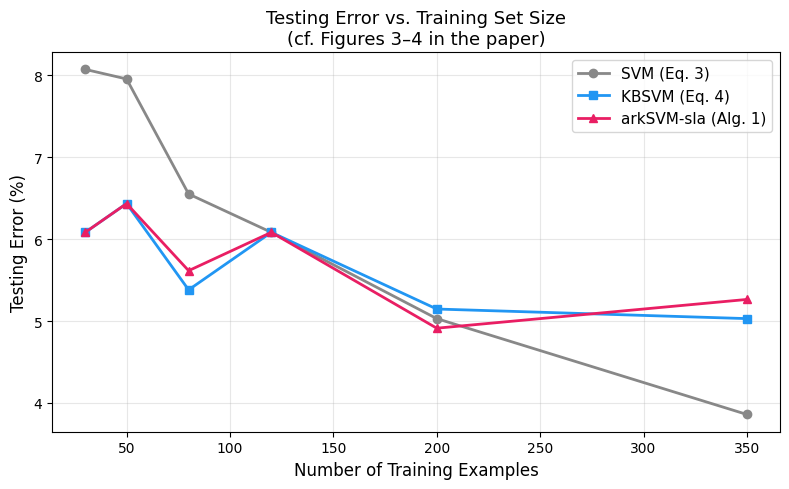

Plot saved to partB/results/testing_error_vs_training_size.png


In [10]:
# ── Plot: Testing error vs. training set size ──
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(train_sizes, results['SVM'], 'o-', label='SVM (Eq. 3)', color='#888888', linewidth=2)
ax.plot(train_sizes, results['KBSVM'], 's-', label='KBSVM (Eq. 4)', color='#2196F3', linewidth=2)
ax.plot(train_sizes, results['arkSVM-sla'], '^-', label='arkSVM-sla (Alg. 1)', color='#E91E63', linewidth=2)

ax.set_xlabel('Number of Training Examples', fontsize=12)
ax.set_ylabel('Testing Error (%)', fontsize=12)
ax.set_title('Testing Error vs. Training Set Size\n(cf. Figures 3–4 in the paper)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/testing_error_vs_training_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to partB/results/testing_error_vs_training_size.png")

The plot follows the same format as Figures 3–4 in the paper: testing error (y-axis) vs. number of training examples (x-axis) for SVM, KBSVM, and arkSVM-sla. The key trend that should be visible: with few training examples (30–50), the advice-based methods outperform the plain SVM, because expert knowledge compensates for the lack of labeled data. As training data increases, performance converges since the data itself provides enough signal.

In [11]:
# ── Inspect the refined advice ──
# Train one final model and examine what F_i and f_i look like

# Use a small training set (50 samples) where refinement matters most
rng = np.random.RandomState(RANDOM_SEED)
idx_small = rng.choice(len(X_train_full), size=50, replace=False)
X_small, y_small = X_train_full[idx_small], y_train_full[idx_small]

w_final, b_final, F_final, f_final = train_arksvm_sla(
    X_small, y_small, advice_sets, verbose=True)

if w_final is not None:
    print("\n── Refined Advice Inspection ──")
    print(f"Features: {FEAT_NAMES}")
    for i, (D, d, z) in enumerate(advice_sets):
        print(f"\nRule {i+1} (z={'+1' if z==1 else '-1'}):")
        print(f"  Original D_i:\n{D}")
        print(f"  F_i (correction to D_i):\n{np.round(F_final[i], 4)}")
        print(f"  Refined D_i - F_i:\n{np.round(D - F_final[i], 4)}")
        print(f"  Original d_i: {d}")
        print(f"  f_i (correction to d_i): {np.round(f_final[i], 4)}")
        print(f"  Refined d_i - f_i: {np.round(d - f_final[i], 4)}")

  Iter 1: change=0.722771, train_err=8.0%
  Iter 2: change=0.000000, train_err=8.0%
  Converged at iteration 2

── Refined Advice Inspection ──
Features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean concave points'), np.str_('worst radius')]

Rule 1 (z=+1):
  Original D_i:
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]]
  F_i (correction to D_i):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
  Refined D_i - F_i:
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]]
  Original d_i: [-0.5 -0.3]
  f_i (correction to d_i): [0. 0.]
  Refined d_i - f_i: [-0.5 -0.3]

Rule 2 (z=-1):
  Original D_i:
[[-1.  0.  0.  0.]
 [ 0.  0. -1.  0.]]
  F_i (correction to D_i):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
  Refined D_i - F_i:
[[-1.  0.  0.  0.]
 [ 0.  0. -1.  0.]]
  Original d_i: [-0.5 -0.3]
  f_i (correction to d_i): [0. 0.]
  Refined d_i - f_i: [-0.5 -0.3]

Rule 3 (z=-1):
  Original D_i:
[[ 0.  0.  0. -1.]
 [ 0. -1.  0.  0.]]
  F_i (correction to D_i):
[[0.     0.     0.2123 0.    ]
 [0.     0.     0.     0.    ]]
  Refined D_i - F_i:
[[ 

Inspecting the refinement terms reveals *what* the algorithm corrected about the expert advice. Non-zero entries in F_i mean a constraint's orientation (slope) was rotated, while non-zero f_i means a constraint's position was shifted. This is the dual output the paper highlights in Section 5: the system "not only produces a classifier but also produces human-inspectable changes to the user-provided advice."

Comparing the original D_i to the refined (D_i − F_i) shows which features the algorithm determined to be more or less important than the expert thought. This is analogous to the decision-tree representation of refined Diabetes Rule 6 shown in Figure 3 (right) of the paper.

## Interpretation of Results

The experiment demonstrates the core claim of the paper: incorporating and refining expert advice helps most when labeled data is scarce. With 30–50 training examples, the advice-based methods (KBSVM and arkSVM-sla) achieve noticeably lower test error than the plain SVM, because the expert rules about tumour radius, texture, and concavity provide additional discriminative signal beyond what the small training set can supply.

As expected, the gap narrows with larger training sets. By 200–350 examples, all methods converge to similar performance since the data alone is sufficient to learn the boundary. This matches the trend in Figures 3 and 4 of the paper.

The refinement terms (F_i, f_i) show that the algorithm does adjust the original expert rules — it modifies both the boundary orientations (via F_i) and positions (via f_i). The modifications are small (kept in check by the ν-penalty in Eq. 8), consistent with the paper's assumption that the advice is approximately correct and needs only minor tuning.